In [84]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [85]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_wx,target_az,target_tmp,target_ay,target_e,target_ax,target_roll,target_yaw,target_pitch,target_wy,target_wz,static
0,0.0,32.10761,1.472733,55.4,10.080864,0.0,-0.115061,20.617,5.425,9.819,-2.15687,-20.81148,False
1,0.1,24.00785,1.332871,55.5,9.576998,0.0,-0.033117,23.347,4.695,11.864,-1.23790,-14.74208,False
2,0.2,14.67136,1.309806,55.4,9.160235,0.0,0.034147,25.234,4.135,13.237,-0.37318,-8.57073,False
3,0.3,4.75546,1.220251,55.5,8.941507,0.0,0.076600,26.179,3.886,13.824,0.07954,-1.27825,False
4,0.4,-6.16720,1.223262,55.5,9.048145,0.0,0.131252,26.114,3.952,13.599,0.03520,5.46247,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,469.5,-0.22118,1.563857,62.3,9.621706,0.0,0.223847,9.052,357.174,1.283,-0.30304,-0.22107,True
4697,469.6,-0.25937,1.544302,62.1,9.652754,0.0,0.199948,9.048,357.172,1.280,-0.10952,-0.08764,True
4698,469.7,0.14069,1.544920,62.0,9.662796,0.0,0.231329,9.046,357.171,1.279,-0.05265,0.01269,True
4699,469.8,-0.00101,1.532122,62.1,9.721332,0.0,0.222238,9.048,357.171,1.275,0.05136,0.16285,True


In [86]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_wx,ref_az,ref_q1,ref_ay,ref_la_pos_mon_d,ref_ax,ref_roll,ref_q0,ref_yaw,ref_pitch,ref_q3,ref_wy,ref_sample_time,ref_wz,ref_q2,static
0,0.0,3.766625,0.189200,0.7086,-10.550,-0.08849,0.024890,91.157585,0.6483,-28.928639,15.194841,-0.2647,0.346353,105000000.0,-38.044398,-0.08719,False
1,0.1,3.583851,0.167100,0.7128,-10.080,-0.11040,-0.003167,91.558656,0.6386,-28.808318,18.306002,-0.2817,0.370876,205000000.0,-28.292656,-0.06853,False
2,0.2,2.936982,0.094150,0.7158,-9.652,-0.12630,-0.019120,91.902430,0.6316,-28.699456,20.317083,-0.2925,0.368928,305000000.0,-16.965280,-0.05654,False
3,0.3,1.835757,0.010680,0.7175,-9.352,-0.13230,-0.022650,92.131613,0.6282,-28.613512,21.130683,-0.2965,0.363198,405000000.0,-4.724037,-0.05171,False
4,0.4,0.433729,-0.056640,0.7177,-9.253,-0.12690,-0.012660,92.246205,0.6288,-28.636431,20.700965,-0.2941,-0.378209,505000000.0,7.740660,-0.05465,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,469.5,-0.006394,-0.008379,0.6544,-9.786,-0.17950,0.085370,89.954374,0.6480,-45.848083,1.495993,-0.2841,-0.027932,605000000.0,0.002796,-0.26670,True
4697,469.6,-0.000966,-0.007153,0.6544,-9.786,-0.17900,0.085840,89.954374,0.6480,-45.848083,1.494847,-0.2841,-0.025669,705000000.0,-0.005810,-0.26670,True
4698,469.7,0.003132,-0.006557,0.6544,-9.786,-0.17860,0.086080,89.954374,0.6480,-45.848083,1.493701,-0.2841,-0.018398,805000000.0,0.015602,-0.26670,True
4699,469.8,0.010153,-0.008756,0.6544,-9.786,-0.17810,0.086660,89.954374,0.6480,-45.853812,1.494274,-0.2841,-0.014118,905000000.0,-0.008417,-0.26680,True


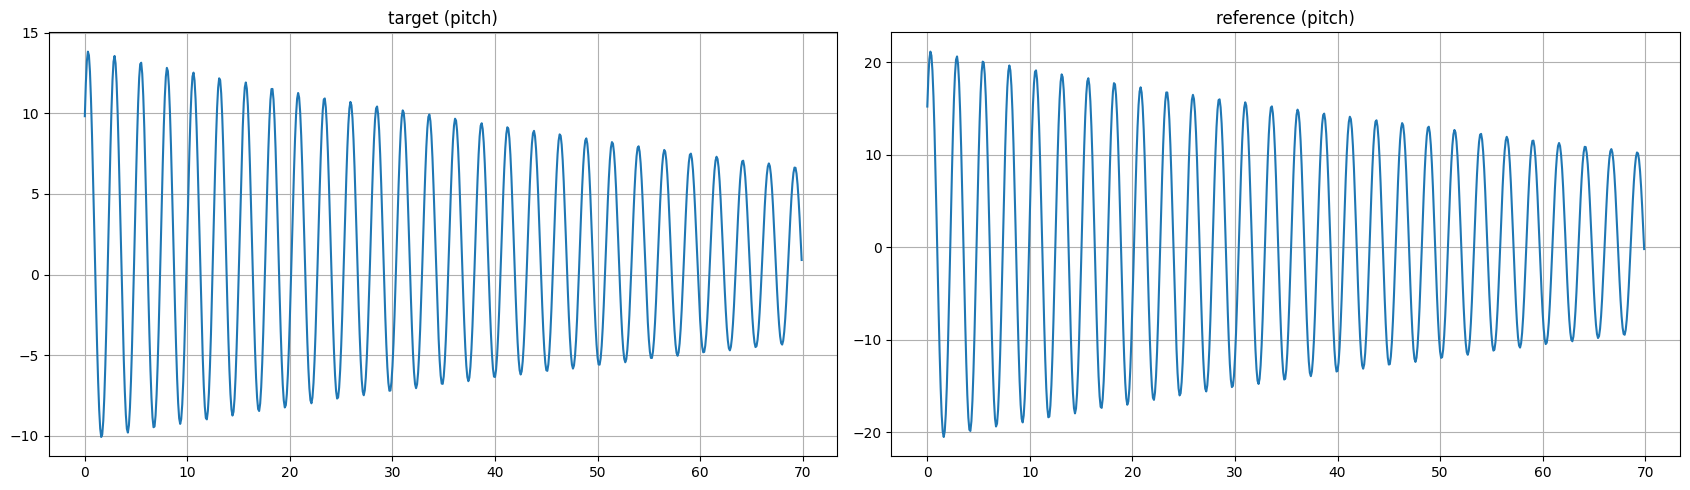

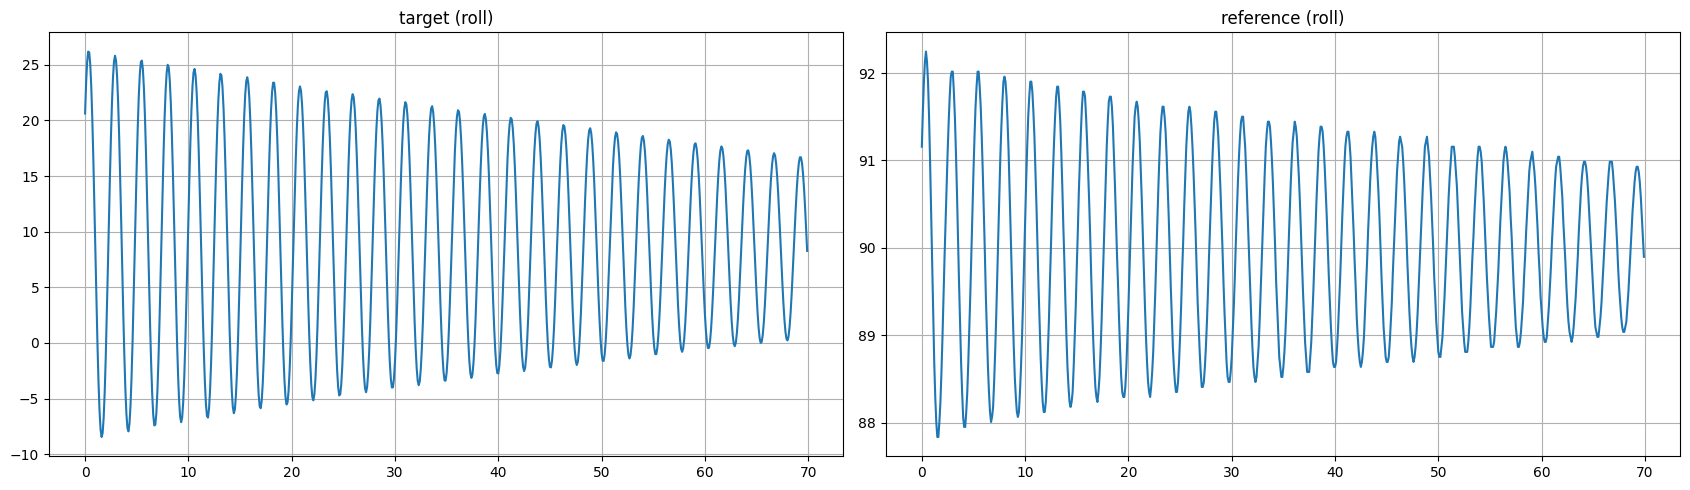

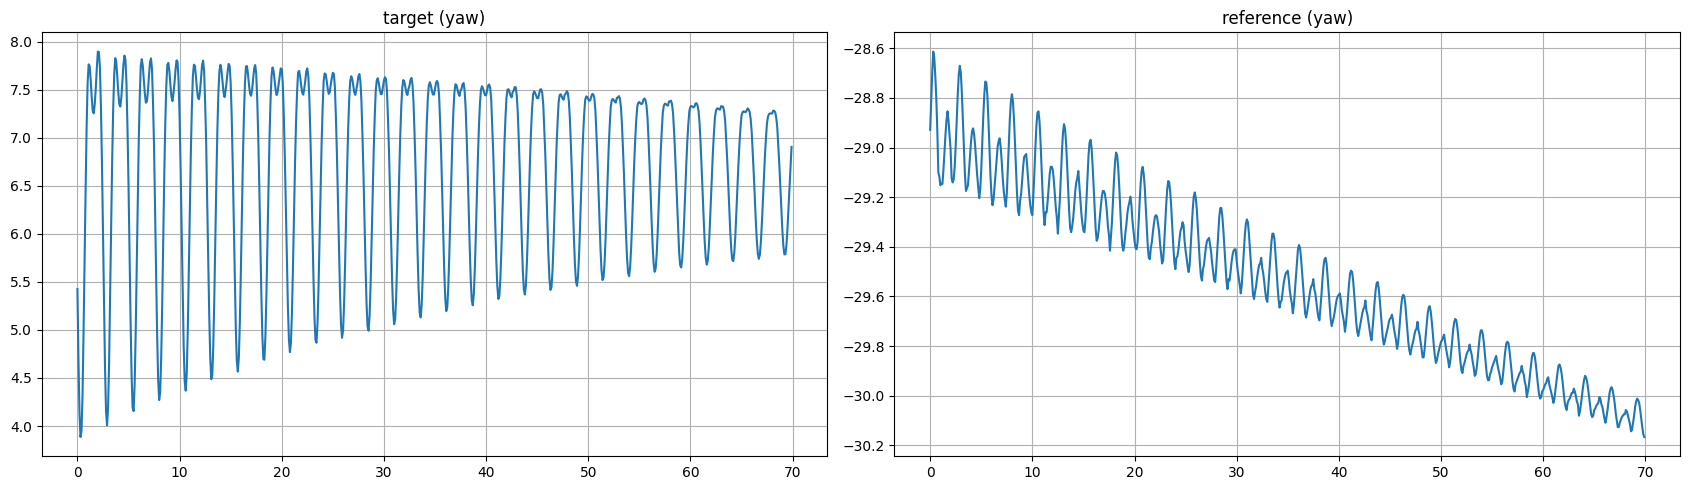

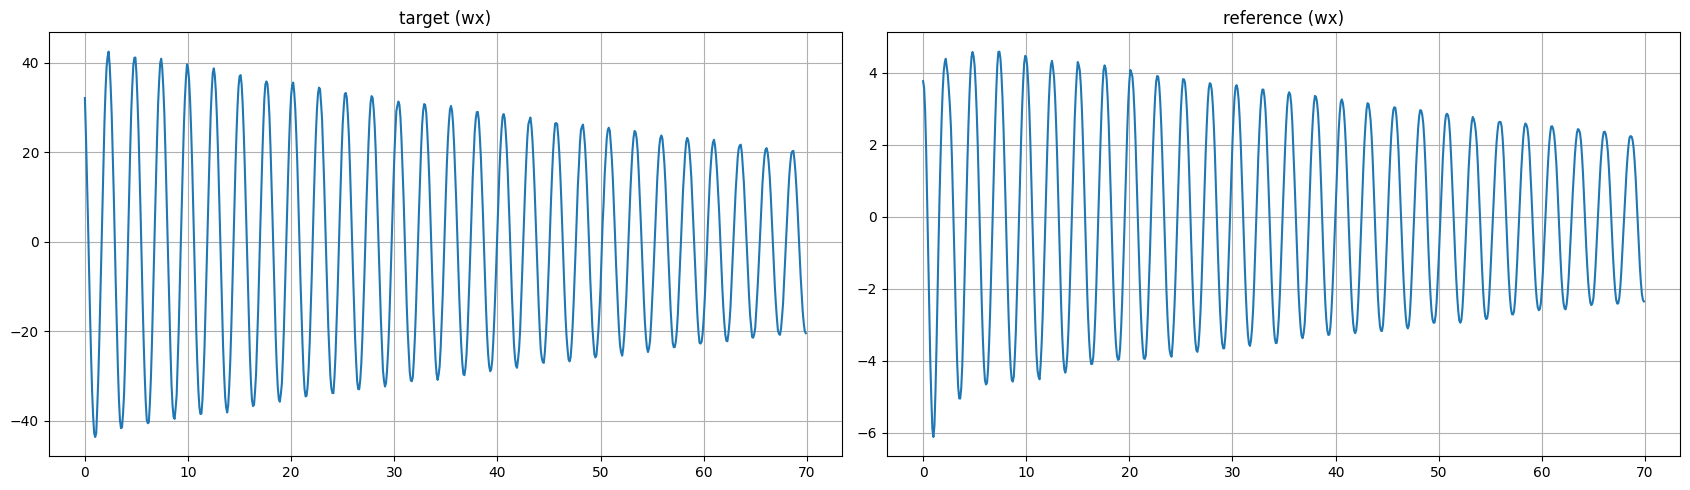

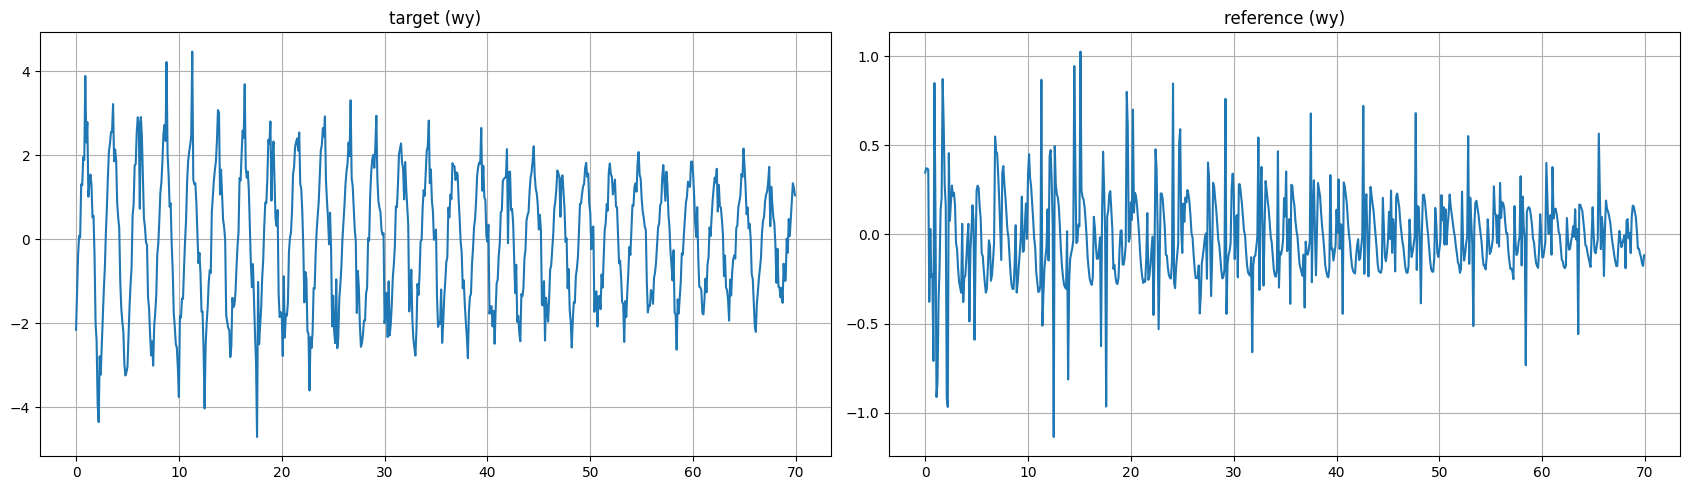

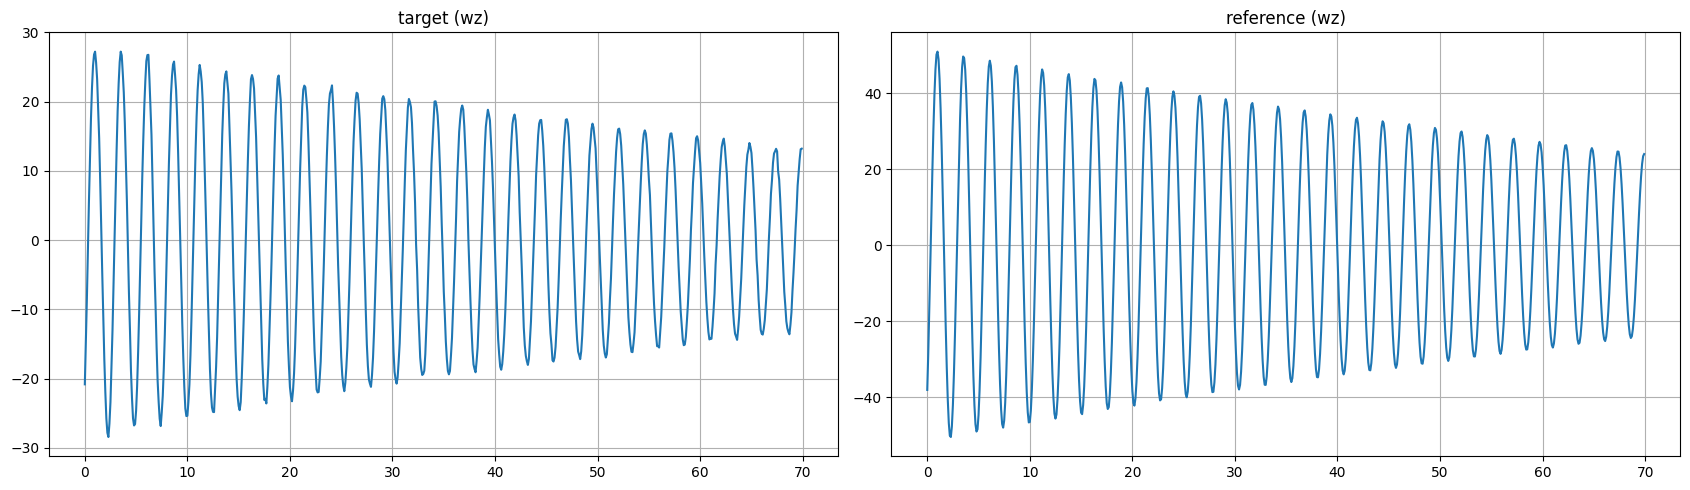

In [87]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target.loc[~df_target.static][f'target_{var}'], 
        f'reference ({var})': df_ref.loc[~df_ref.static][f'ref_{var}']
    }, time=df_ref.loc[~df_ref.static].time, figsize=(17, 5))

In [88]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_wx,target_az,target_tmp,target_ay,target_e,target_ax,target_roll,target_yaw,target_pitch,target_wy,target_wz,static,ref_wx,ref_az,ref_q1,ref_ay,ref_la_pos_mon_d,ref_ax,ref_roll,ref_q0,ref_yaw,ref_pitch,ref_q3,ref_wy,ref_sample_time,ref_wz,ref_q2
0,0.0,32.10761,1.472733,55.4,10.080864,0.0,-0.115061,20.617,5.425,9.819,-2.15687,-20.81148,False,3.766625,0.189200,0.7086,-10.550,-0.08849,0.024890,91.157585,0.6483,-28.928639,15.194841,-0.2647,0.346353,105000000.0,-38.044398,-0.08719
1,0.1,24.00785,1.332871,55.5,9.576998,0.0,-0.033117,23.347,4.695,11.864,-1.23790,-14.74208,False,3.583851,0.167100,0.7128,-10.080,-0.11040,-0.003167,91.558656,0.6386,-28.808318,18.306002,-0.2817,0.370876,205000000.0,-28.292656,-0.06853
2,0.2,14.67136,1.309806,55.4,9.160235,0.0,0.034147,25.234,4.135,13.237,-0.37318,-8.57073,False,2.936982,0.094150,0.7158,-9.652,-0.12630,-0.019120,91.902430,0.6316,-28.699456,20.317083,-0.2925,0.368928,305000000.0,-16.965280,-0.05654
3,0.3,4.75546,1.220251,55.5,8.941507,0.0,0.076600,26.179,3.886,13.824,0.07954,-1.27825,False,1.835757,0.010680,0.7175,-9.352,-0.13230,-0.022650,92.131613,0.6282,-28.613512,21.130683,-0.2965,0.363198,405000000.0,-4.724037,-0.05171
4,0.4,-6.16720,1.223262,55.5,9.048145,0.0,0.131252,26.114,3.952,13.599,0.03520,5.46247,False,0.433729,-0.056640,0.7177,-9.253,-0.12690,-0.012660,92.246205,0.6288,-28.636431,20.700965,-0.2941,-0.378209,505000000.0,7.740660,-0.05465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,469.5,-0.22118,1.563857,62.3,9.621706,0.0,0.223847,9.052,357.174,1.283,-0.30304,-0.22107,True,-0.006394,-0.008379,0.6544,-9.786,-0.17950,0.085370,89.954374,0.6480,-45.848083,1.495993,-0.2841,-0.027932,605000000.0,0.002796,-0.26670
4697,469.6,-0.25937,1.544302,62.1,9.652754,0.0,0.199948,9.048,357.172,1.280,-0.10952,-0.08764,True,-0.000966,-0.007153,0.6544,-9.786,-0.17900,0.085840,89.954374,0.6480,-45.848083,1.494847,-0.2841,-0.025669,705000000.0,-0.005810,-0.26670
4698,469.7,0.14069,1.544920,62.0,9.662796,0.0,0.231329,9.046,357.171,1.279,-0.05265,0.01269,True,0.003132,-0.006557,0.6544,-9.786,-0.17860,0.086080,89.954374,0.6480,-45.848083,1.493701,-0.2841,-0.018398,805000000.0,0.015602,-0.26670
4699,469.8,-0.00101,1.532122,62.1,9.721332,0.0,0.222238,9.048,357.171,1.275,0.05136,0.16285,True,0.010153,-0.008756,0.6544,-9.786,-0.17810,0.086660,89.954374,0.6480,-45.853812,1.494274,-0.2841,-0.014118,905000000.0,-0.008417,-0.26680


In [89]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)